Answers for Week 7

* Name: Sophie Leszek
* Username: zeleszek
* Student s-number: s5686709
* Group (AS1, etc.): AS5

In [114]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from scipy import interpolate as ip
from scipy.optimize import leastsq, curve_fit

In [28]:
#7.1

#matrix
A = np.array([1,2,3, 0,-4,1, 0,3,-1]).reshape(3,3)

#1. determinant
det = la.det(A)
print(f"determinant of A:", det)

#2. solution to equations
b = np.array([2,2,1])
Ainv = la.inv(A)
xyz = Ainv@b

print(f"\nSolution: x, y, z = {xyz}")

#3. orthogonal? 
print(f"\northogonal?\nMatrix A:\n{A}")
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")
print(f"\nInverse of A:\n{la.inv(A)}")
print(f"\nis equal to the transpose:\n{A.T}")
print(f"\nAlternative check with function array_equal(): {np.array_equal(A.T, la.inv(A))}")
print(f"\nAlternative check with function allclose(): {np.allclose(A.T, la.inv(A))}")

#eigenvalues
Lambda, v = la.eig(A)
print(f"\neigenvalues:", Lambda)

determinant of A: 1.0

Solution: x, y, z = [ 38.  -3. -10.]

orthogonal?
Matrix A:
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]

Inverse of A:
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]

is equal to the transpose:
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

Alternative check with function array_equal(): False

Alternative check with function allclose(): False

eigenvalues: [ 1.         -4.79128785 -0.20871215]


In [64]:
#7.3

#E = E_z(180-123) * E_y(90-27.4) * E_z(192.25) (eq. 7.15)

a = np.radians(180-123)
b = np.radians(90-27.4)
g = np.radians(192.25)

Ez1 = np.array([np.cos(a),np.sin(a),0,
              -np.sin(a), np.cos(a), 0,
              0, 0, 1]).reshape(3,3)
Ey = np.array([np.cos(b),0,-np.sin(b),
              0, 1, 0,
              np.sin(b), 0, np.cos(b)]).reshape(3,3)
Ez2 = np.array([np.cos(g),np.sin(g),0,
              -np.sin(g), np.cos(g), 0,
              0, 0, 1]).reshape(3,3)


E = Ez1 @ Ey @ Ez2
print(E)

print(f"\nrotational matrix:", np.allclose(E.T @ E, np.eye(3)) and np.linalg.det(E) == 1)

#eigenvalues
Lambda, v = la.eig(E)
print(f"\neigenvalues:", Lambda)

#vector and norm
alpha = np.radians(192.25)
delta = np.radians(27.4)

v = np.array([np.cos(delta)*np.cos(alpha),
             np.cos(delta)*np.sin(alpha),
             np.sin(delta)]).reshape(3, 1)
print(f"\nvector v:", v)
print(f"norm:", la.norm(v))

#rotating v
v2 = E @ v
print(f"\nv2 =", v2)
print(f"rounded; \nv2 =", np.round(v2, 10))

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

rotational matrix: True

eigenvalues: [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]

vector v: [[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
norm: 1.0

v2 = [[2.77555756e-17]
 [5.55111512e-17]
 [1.00000000e+00]]
rounded; 
v2 = [[0.]
 [0.]
 [1.]]


coefficients: [ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331360e+01  2.91867715e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


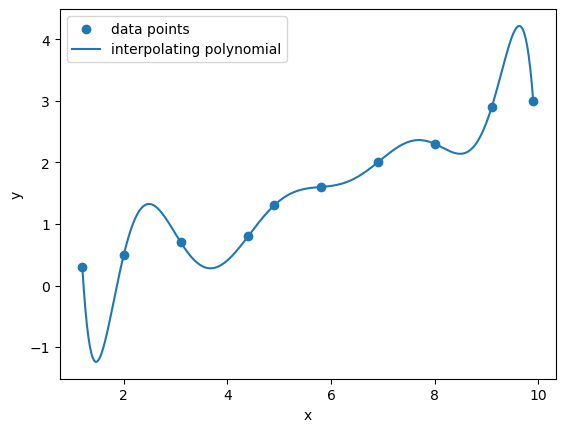

In [74]:
#7.5

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

#polynomial: a0 + a1x + a2x^2 + ... + anx^n
n = len(x)

#vandermonde matrix:
A = np.zeros((n, n)) #starting w empty matrix
for i in range(n):
    for j in range(n):
        A[i, j] = x[i] ** j 

#coefficients:
c = la.solve(A, y)
print(f"coefficients:", c)

#plot
plt.scatter(x, y, label="data points") #data points

x_plot = np.linspace(min(x), max(x), 300)

y_plot = np.zeros_like(x_plot)
for i in range(len(c)):
    y_plot += c[i] * x_plot**i #polynomial

plt.plot(x_plot, y_plot, label="interpolating polynomial")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()



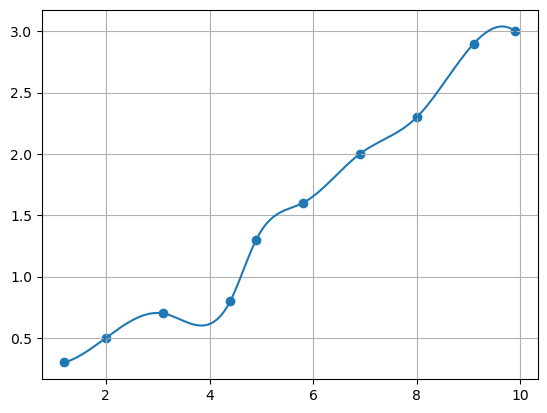

Y_hat for X_hat = 5
using linear interpolation: 1.3333333333333333
using polynomial interpolation: 1.3731301577433896
using spline interpolation: 1.3744762382675273


In [105]:
#7.6

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
 
f = ip.interp1d(x, y, kind='cubic') #spline

X = np.linspace(min(x),max(x),250)  #points within x
Y = f(X)

#plotting
fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y) #data
frame.plot(X, Y) #interpolating spline
frame.grid(True)
plt.show()

#thoughts: much simpler:) - plot from 7.5 wiggles about much more, 
#maximum and minimum varies much more from the data points, 
#here it's much closer to the provided data 

#creating the object...
class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.X = np.linspace(min(x), max(x), 300) #for when X isn't provided (fallback)
        
    def linear(self, X=None):
        if X is None:
            X = self.X #fallback for when X isn't provided 
            
        return np.interp(X, self.x, self.y)
        
    def poly(self, X=None):
        if X is None:
            X = self.X #fallback 
        #code from 7.5...    
        n = len(self.x)
        
        A = np.zeros((n, n))
        
        for i in range(n):
            for j in range(n):
                A[i, j] = self.x[i] ** j
        c = la.solve(A, self.y)
        
        Y = np.zeros_like(X, dtype=float) #float making sure the code stays afloat;)
        for i in range(len(c)):
            Y += c[i] * X**i
            
        return Y if Y.size > 1 else Y.item() #if clause cuz what if X provided is a singular number (making it work for X_hat)
        
    def spline(self, X=None):
        if X is None:
            X = self.X #fallback
            
        f = ip.interp1d(self.x, self.y, kind='cubic') #and spline:)
        return f(X)

    def evaluate(self, X_hat, method="poly"): #the function requiring X_hat
        #range:
        if np.any(X_hat < min(self.x)) or np.any(X_hat > max(self.x)):
            raise ValueError("X_hat is outside interpolation range") #so that X_hat meets the requirement 

        if method == "linear":
            return self.linear(X_hat)
            
        elif method == "poly":
            return self.poly(X_hat)
        
        elif method == "spline": 
            return self.spline(X_hat)
        else:
            raise ValueError("Unknown method") #just in case


#Testing
X_hat = 5
i = interpolation(x, y)

print(f"Y_hat for X_hat =", X_hat)

Y_lin = i.evaluate(X_hat, method="linear")
print(f"using linear interpolation:", Y_lin)

Y_poly = i.evaluate(X_hat)
print(f"using polynomial interpolation:", Y_poly)

Y_spline = i.evaluate(X_hat, method="spline")
print(f"using spline interpolation:", Y_spline)

In [110]:
#7.7

I = np.array([[2.0,4.1], [2.5,3.8]]) 
x=0.2 #lambda
y=0.7 #mu

#I_ip = (1-x)(1-y)I_0 + x(1-y)I_1 + y(1-x)I_2 + xyI_3

I0 = I[0,0]
I1 = I[0,1]
I2 = I[1,0]
I3 = I[1,1]

I_ip = (1-x)*(1-y)*I0 + x*(1-y)*I1 + y*(1-x)*I2 + x*y*I3

print(f"intensity at x = {x} and y = {y}: I_ip =", I_ip)

intensity at x = 0.2 and y = 0.7: I_ip = 2.658


Params:                          [69.93805979 64.13233494]
Unscaled standard error(s):      [47.32288249  1.52711792]
Scaled standard error(s):        [348.23437453  11.23758582]
Degrees of freedom:              11
Chi^2 min:                       595.6533407328835
Reduced Chi squared:             54.15030370298941
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7

Intercept beta0=69.9377803016813, slope beta1=64.13234247590542


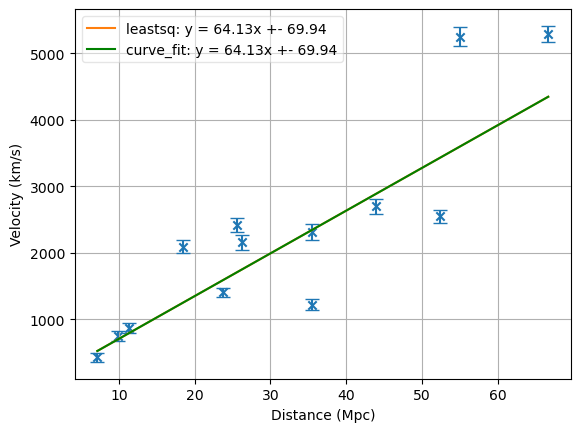

In [141]:
#7.10

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data = np.asarray(data)
x = data[0::4]; y = data[1::4]
sigx= data[2::4]; sigy= data[3::4]

#leastsq:
# The model, usually a function of x
def model_lsq(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model_lsq(beta,x))/sigy

beta_start = [0, 70.0]          #initial estimates for beta0 and beta1
data = (x, y, sigy)             #data into tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result #unpacking

#unscaled standard errors into scaled standard errors
if not pcov is None:
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        
    dof = len(fvec) - len(beta)              
    sderr = perror * np.sqrt(chi2/dof)

print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_lsqwei = beta

#curve fit:
def model_cf(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

#fitting
beta_cf, pcov = curve_fit(model_cf, x, y, sigma=sigy)
print(f"\nIntercept beta0={beta_cf[0]}, slope beta1={beta_cf[1]}")

#end points for the best straight line
X = np.array([x.min(),x.max()])
Y = model_cf(X, beta[0], beta[1])

#plotting
Y_lsq = beta_lsqwei[0] + beta_lsqwei[1]*X

fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='x')
frame.errorbar(x, y, sigy, ls='', capsize=5)
frame.plot(X, Y_lsq, label=f"leastsq: y = {beta_lsqwei[1]:.2f}x +- {beta_lsqwei[0]:.2f}")
frame.plot(X, Y, color='green', label=f"curve_fit: y = {beta_cf[1]:.2f}x +- {beta_cf[0]:.2f}")

frame.set_xlabel('Distance (Mpc)')
frame.set_ylabel('Velocity (km/s)')
frame.legend(fancybox=True, framealpha=0.5)
frame.grid(True)

plt.show()

In [7]:
#7.14

